# Data Visualisation

<a id='Index'></a>
# Exercise list:
* <a href='#Exercise-01'>Exercise-01</a>
* <a href='#Exercise-02'>Exercise-02</a>
* <a href='#Exercise-03'>Exercise-03</a>
* <a href='#Exercise-04'>Exercise-04</a>
* <a href='#Exercise-05'>Exercise-05</a>

## Main objectives:

* Produce the relevant Pieplot, Barplot, Correlation Matrix to analyse the dataset
  * using **Pandas** DataFrames (vs. Spark in the ML Notebooks)
  * using matplotlib (imported as **plt**) and seaborn (imported as **sns**)



In [1]:
%spark 16 32g

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/01 15:47:21 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.4.2
      /_/

Using Python version 3.9.18 (main, Dec 15 2023 17:48:57)
Spark context Web UI available at None
Spark context available as 'sc' (master = local[*], app id = local-1759326442243).
SparkSession available as 'spark'.


In [2]:
%run handlers.ipynb

Pandas version:  2.1.4


# Read-in the DataFrames from manipulation 

* Read-in the **training** Spark DataFrame **df_train** = S-Bahn + Weather information, including the delays at the stations -1,-2

* Also create a **pandas** version of df_train: **df_train_pd**
* Pre-saved data are in the read-only directory **local_data_dir_ro**. Data you produced e.g. in the previous notebook are in **local_data_dir**.


In [3]:
# Read-in Manipulation DataFrames 
df_names= ['df_train'+suffix_s_w+'.csv', \
           'df_test'+suffix_s_w+'.csv', \
           'df_train_classification'+suffix_s_w+'.csv', \
           'df_test_classification'+suffix_s_w+'.csv']

path_lustre = []
for filename in df_names:
    path_lustre.append(os.path.join(local_data_dir_ro, filename))

print("Reading in df_train from manipulation in... ")
start_time = time.time()
path=os.path.join(LustrePrefix,path_lustre[0])
df_train = spark.read.option('header', True).option('inferSchema', True).csv(os.path.join(LustrePrefix,path_lustre[0])).cache()
print("--- %.0f min. %.2f sec.---" % (np.floor_divide(time.time() - start_time, 60),
    np.remainder(time.time() - start_time, 60)))

# Replace the S-Bahn line numbers with S-Bahn line numbers cast to STRING 
df_train = df_train.withColumn('ZUGEREIGNIS_LINIE',df_train['ZUGEREIGNIS_LINIE'].cast(StringType())) 
# List of all S-Bahn lines in the DataBase: 
list_linie = df_train.select('ZUGEREIGNIS_LINIE').distinct().rdd.flatMap(lambda x: x).collect() 
print("S-Bahn lines:", list_linie)  

Reading in df_train from manipulation in... 


25/10/01 15:47:45 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


--- 0 min. 3.56 sec.---


S-Bahn lines: ['11', '3', '5', '6', '60', '1', '4', '2']


In [4]:
# Convert the DataFrame to Pandas 
df_train_pd = DataVisualize_ext.convert_to_pandas(df_train)

* Have a look at the Pandas DataFrame with **iloc** (implicit indices):

In [5]:
df_train_pd.iloc[:5,:]

,MONAT,TAG,STUNDE_SOLL,MINUTE_RANGE,ZUGEREIGNIS_LINIE,SERVICE_START_ZEIT,ZUGEREIGNIS_ISTZEIT,ZUGEREIGNIS_TYP,ZUGEREIGNIS_SOLLZEIT,SERVICE_ID,...,Mittel_WG,Max_WG,Summe_Niederschalg,Mittel_NO,Mittel_NO2,Mittel_O3,Mittel_PM10,TimeUnix,prev0_VERSPAETUNG,prev1_prev0_VERSPAETUNG
0,9,1,0,30,1,1504216260,1504218660,40,1504218660,30073245647,...,0.8,1.5,0.2,0.6,15.1,25.6,0.0,1504218600,0,0
1,9,1,0,30,1,1504216260,1504219140,40,1504219140,30073245647,...,0.8,1.5,0.2,0.6,15.1,25.6,0.0,1504218600,0,0
2,9,1,0,30,1,1504216800,1504218780,40,1504218720,30120708901,...,0.8,1.5,0.2,0.6,15.1,25.6,0.0,1504218600,0,0
3,9,1,0,30,1,1504216800,1504219020,40,1504219020,30120708901,...,0.8,1.5,0.2,0.6,15.1,25.6,0.0,1504218600,1,1
4,9,1,0,30,1,1504216800,1504219140,40,1504219140,30120708901,...,0.8,1.5,0.2,0.6,15.1,25.6,0.0,1504218600,0,1


<a href='#Index'>Exercise Index</a>
<a id='Exercise-01'></a>

**EXERCISE 1**
* Use **loc** to print out e.g. 15 rows and 1 or 2 columns of your choice with **explicit** indices.
* Select e.g. the column VERSPAETUNG: delay in minutes.
* Search for DataFrame.loc for info in https://pandas.pydata.org/pandas-docs/stable/index.html 

In [8]:
df_train_pd.loc[0:14, ['VERSPAETUNG']]

,VERSPAETUNG
0,0
1,0
2,1
3,0
4,0
5,0
6,0
7,1
8,0
9,0


# Get statistical information from the DataFrame

* We compute a new, small **Pandas DataFrame (df_pd_stats)** containing, for each S-Bahn line:
  * **count**: Total number of events (i.e., stops of the train)
  * **max** / **mean**/ **min** (=0):  Aggregated info (in minutes) about the delay

* In **handlers**, the user-defined function **calcStats** in the class "DataVisualize" combines
  * groupby(): group the data according to a parameter (ZUGEREIGNIS_LINIE)
  * the statistics min(), max(), count(), mean()

In [9]:
df_pd_stats = DataVisualize.calcStats(df_train_pd)
print(df_pd_stats)

                   min    max    count      mean
ZUGEREIGNIS_LINIE                               
11                 0.0   46.0     52.0  7.807692
60                 0.0  100.0  17583.0  0.866234
5                  0.0   39.0  21111.0  0.912842
4                  0.0   39.0  26817.0  0.901891
6                  0.0  151.0  29630.0  0.846068
3                  0.0   50.0  43262.0  1.623758
2                  0.0   65.0  57561.0  1.545977
1                  0.0  102.0  62937.0  1.877814


# Pie-plot

* The block below produces **two pie-plots** according to the statistics **count** and **mean** of df_pd_stats.

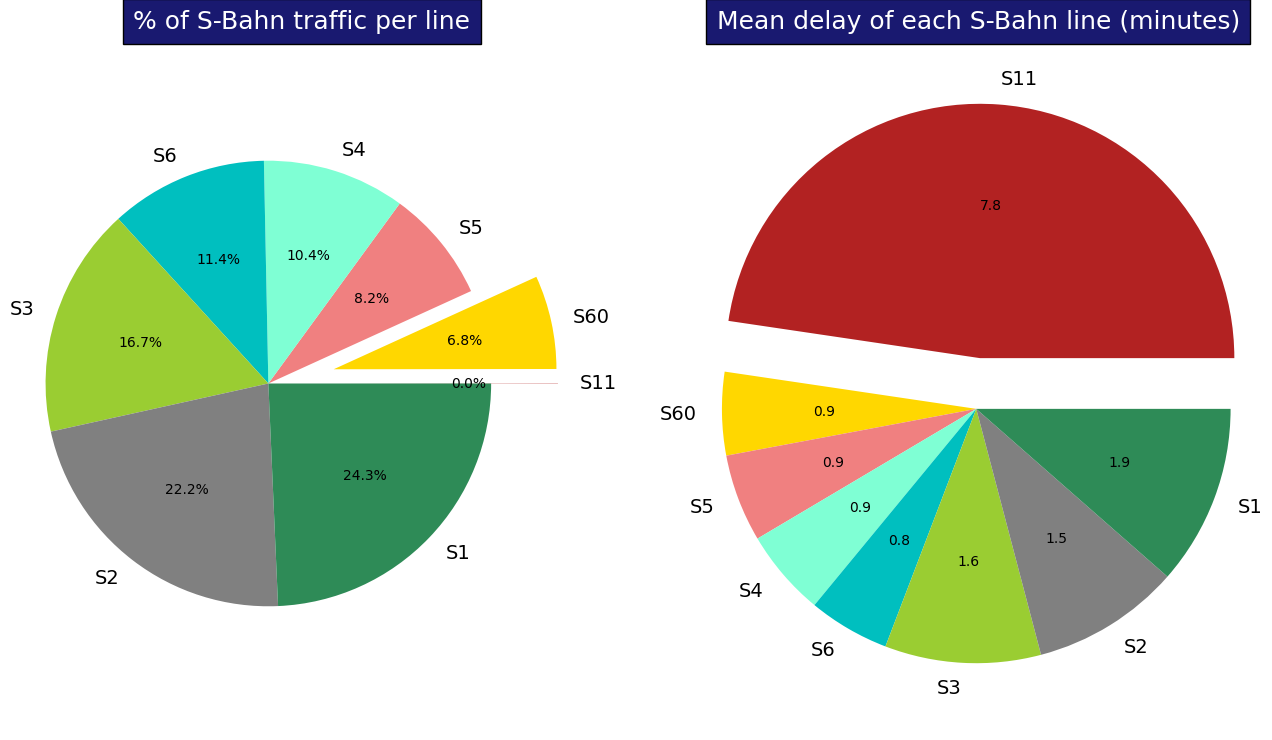

In [10]:
colors = ['firebrick', 'gold', 'lightcoral', 'aquamarine', 'c', 'yellowgreen', 'grey',
          'seagreen']

fig = plt.figure(1, figsize = (16,9))
# Define two subplots:
gs = gridspec.GridSpec(1, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Define the labels as S1, S2, etc.
labels = ['S' + s for s in df_pd_stats.index]
sizes = df_pd_stats['count'].values

# ax1: Number of events (count)

# Explode: how much the slices must come forward (if at all)
# Criterium: Lines with less than 20K observed events
explode = [0.3 if sizes[i] < 20000 else 0.0 for i in range(len(list_linie))]

# autopct: Number of digits as %
patches, texts, autotexts = ax1.pie(sizes, explode = explode,\
                                   labels = labels, colors = colors, autopct = '%1.1f%%',\
                                   shadow = False, startangle = 0)

# Set font, title
for i in range(len(list_linie)):
    texts[i].set_fontsize(14)
ax1.axis('equal')
ax1.set_title('% of S-Bahn traffic per line', bbox = {'facecolor':'midnightblue', 'pad':5},\
             color = 'w', fontsize=18)

# Set legend
# comp_handler = []
# for i in range(len(list_linie)):
#     comp_handler.append(mpatches.Patch(color = colors[i],\
#                                      label = 'S' + list_linie[i]))
# ax1.legend(handles = comp_handler,\
#           fontsize = 13, bbox_transform = plt.gcf().transFigure)

# ax2: Mean delay of each S-Bahn line

sizes = df_pd_stats['mean'].values
# Make sure that a negative mean is shown as 0 delay
sizes = [max(s, 0) for s in sizes]

# Highlight delays over 2 minutes:
explode = [0.0 if sizes[i] < 2 else 0.2 for i in range(len(list_linie))]

# autopct is now defined through a lambda function...
patches, texts, autotexts = ax2.pie(sizes, explode = explode, labels = labels, colors = colors, \
                                shadow = False, startangle = 0,\
                                autopct = lambda p: '{:.1f}'.format(p*sum(sizes)/100))

# Set font, title
for i in range(len(list_linie)):
    texts[i].set_fontsize(14)
ax2.axis('equal')
ax2.set_title('Mean delay of each S-Bahn line (minutes)', bbox = {'facecolor':'midnightblue', 'pad':5},\
             color = 'w', fontsize = 18)

# Save
filename = 'Pieplot'+suffix_s_w
path = os.path.join(LustrePrefix,local_manipulation_plot_dir, filename)
plt.savefig(path)

# Barplot

* Define first a **Lambda function** to obtain the delay "codes" (0,1,2).
* Apply this function to the delay column (VERSPAETUNG) of the Pandas Dataframe df_ts_pd.
* Slice this DataFrame into a smaller one:  Needed are only line number and delay.

* The **lambda function**:

In [11]:
# Lambda function and masking using boolean expression:
# TRUE returns the second element of the tuple, FALSE the first one.

# Compact form:
delay_type = lambda x:((0,1)[x > 2], 2)[x > 10]
# Objective: 0 if x<=2, 1 if 2<x<=10, 2 x>10 
# (0,1)[x > 2] returns y = 0 (if [] FALSE), y = 1 (if [] TRUE)
# (y,2)[x > 2] returns delay_type = y (if [] FALSE), delay_type = 2 (if [] TRUE)

# Alternatively, for better readability:
# delay_type = lambda x: (0 if x <= 2 else 1) if x <=10 else 2

# Apply lambda "delay_type" to replace VERSPAETUNG with the values 0,1,2.
df_train_pd['VERSPAETUNG_TYPE'] = df_train_pd['VERSPAETUNG'].apply(delay_type)

In [12]:
# New DataFrame with only two columns (delay and line number):
df_la_pd = df_train_pd.loc[:,['VERSPAETUNG_TYPE', 'ZUGEREIGNIS_LINIE']]
df_la_pd = df_la_pd.sort_values(by=['ZUGEREIGNIS_LINIE'])

* Use **Seaborn** to produce the **barplot**:

/var/tmp/pbs.21170.cl7intern/ipykernel_3333786/4049971234.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


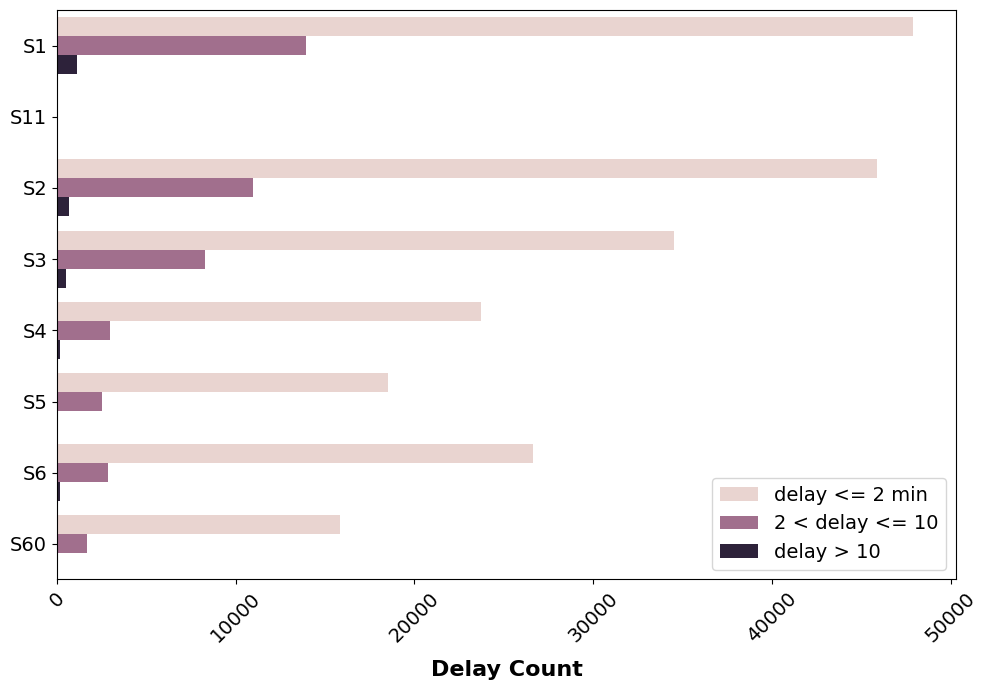

In [13]:
#Set up the plot
fig = plt.figure(2, figsize=(10, 7))

# Define a countplot with Seaborn
# hue = colors according to which variable
ax = sns.countplot(y = 'ZUGEREIGNIS_LINIE', hue = 'VERSPAETUNG_TYPE', data = df_la_pd)

# Tick labels for y axis
labels = [lb.get_text() for lb in ax.get_yticklabels()] #y: ZUGEREIGNIS_LINIE
for i in range(len(labels)):
    labels[i] = 'S' + labels[i]
    
ax.set_yticklabels(labels)

# Set the properties of tick labels x and y:
fontsize_bars = 14
plt.setp(ax.get_xticklabels(), fontsize = fontsize_bars, weight = 'normal', rotation = 45)
plt.setp(ax.get_yticklabels(), fontsize = fontsize_bars, weight = 'normal', rotation = 0)

# No label on y axis:
ax.yaxis.label.set_visible(False) #That would be ZUGEREIGNIS_LINIE
# x axis label:
plt.xlabel('Delay Count', fontsize = 16, weight = 'bold', labelpad = 10)

# Create the legend:
L = plt.legend(fontsize = fontsize_bars)
L.get_texts()[0].set_text('delay <= '+ str(2)+' min')
L.get_texts()[1].set_text(str(2)+' < delay <= '+ str(10))
L.get_texts()[2].set_text('delay > '+ str(10))

#Save picture
fig.tight_layout()
filename = 'Barplot_low'+str(2)+'_up'+str(10)+suffix_s_w
path = os.path.join(LustrePrefix,local_manipulation_plot_dir, filename)

plt.savefig(path)

<a href='#Index'>Exercise Index</a>
<a id='Exercise-02'></a>

**EXERCISE 2**
1. Replace the hard-coded thresholds 2 and 10 with variables, such as low_delay=2 ; up_delay=10
2. Use these variables where needed in the three blocks above (@ lambda function, legend, filename, ...).
3. Change the thresholds to e.g. 4 and 15 minutes.
4. Re-execute the blocks and obtain a new bar plot with a new legend and a new filename.

/var/tmp/pbs.21170.cl7intern/ipykernel_3333786/4142189086.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


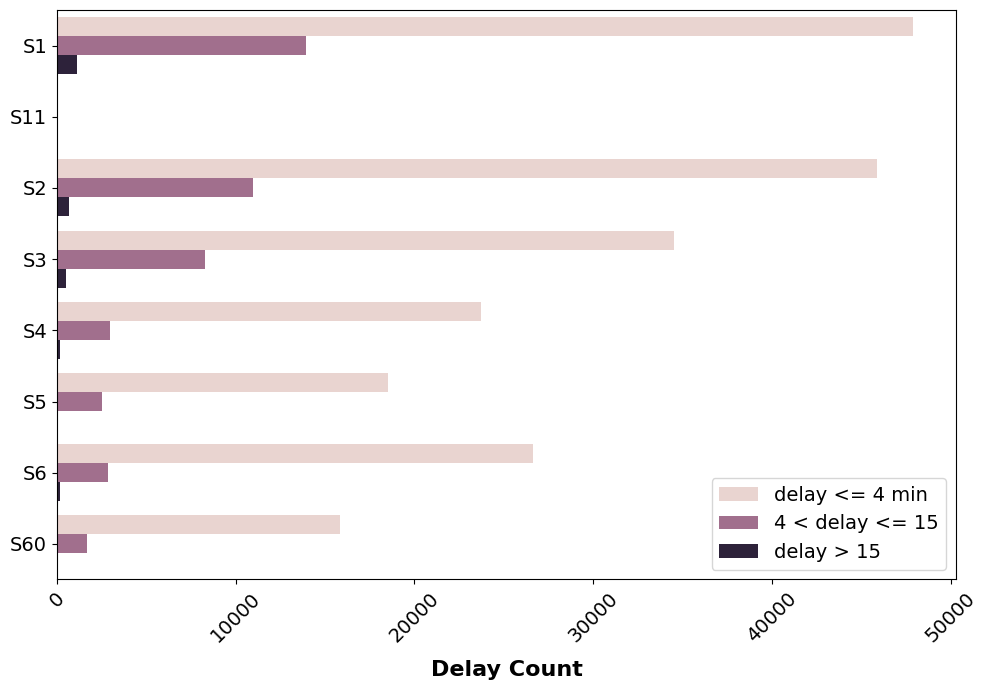

In [14]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define variables for delay thresholds
low_delay = 4
up_delay = 15

# Set up the plot
fig = plt.figure(2, figsize=(10, 7))

# Define a countplot with Seaborn
ax = sns.countplot(y='ZUGEREIGNIS_LINIE', hue='VERSPAETUNG_TYPE', data=df_la_pd)

# Tick labels for y axis
labels = [lb.get_text() for lb in ax.get_yticklabels()]  # y: ZUGEREIGNIS_LINIE
for i in range(len(labels)):
    labels[i] = 'S' + labels[i]
ax.set_yticklabels(labels)

# Set the properties of tick labels x and y:
fontsize_bars = 14
plt.setp(ax.get_xticklabels(), fontsize=fontsize_bars, weight='normal', rotation=45)
plt.setp(ax.get_yticklabels(), fontsize=fontsize_bars, weight='normal', rotation=0)

# No label on y axis:
ax.yaxis.label.set_visible(False)  # That would be ZUGEREIGNIS_LINIE

# x axis label:
plt.xlabel('Delay Count', fontsize=16, weight='bold', labelpad=10)

# Create the legend:
L = plt.legend(fontsize=fontsize_bars)
L.get_texts()[0].set_text(f'delay <= {low_delay} min')
L.get_texts()[1].set_text(f'{low_delay} < delay <= {up_delay}')
L.get_texts()[2].set_text(f'delay > {up_delay}')

# Save picture
fig.tight_layout()
suffix_s_w = ''  # Define suffix according to your context if needed
LustrePrefix = ''  # Define LustrePrefix path if needed
local_manipulation_plot_dir = ''  # Define local path if needed

filename = f'Barplot_low{low_delay}_up{up_delay}{suffix_s_w}'
path = os.path.join(LustrePrefix, local_manipulation_plot_dir, filename)
plt.savefig(path)


<a href='#Index'>Exercise Index</a>
<a id='Exercise-03'></a>

**EXERCISE 3**
## Vectorisation

* For the following analysis, we need to vectorise two categorical columns.
* Observe the two columns **before vectorisation**:

In [15]:
# Convert the DataFrame to Pandas 
df_train_pd = DataVisualize_ext.convert_to_pandas(df_train)

In [16]:
print(df_train_pd.loc[5:10,['ZUGEREIGNIS_DS100','WOCHENTAG_SOLL']])

   ZUGEREIGNIS_DS100 WOCHENTAG_SOLL
5                 TE            Fri
6                 TP            Fri
7               TWER            Fri
8                 TP            Fri
9                 TE            Fri
10              TSOM            Fri


* Then, use Scikit-learn LabelEncoder to transform non-numerical labels into numerical labels.
* Apply the LabelEncoder with **fit_transform(_____)**, which takes as argument the column to be vectorised.
    * https://scikit-learn.org -> sklearn.preprocessing.LabelEncoder

In [18]:
df_train_pd['ZUGEREIGNIS_DS100'] = LabelEncoder().fit_transform(df_train_pd['ZUGEREIGNIS_DS100'])
df_train_pd['WOCHENTAG_SOLL']    = LabelEncoder().fit_transform(df_train_pd['WOCHENTAG_SOLL'])

* Observe the two columns **after vectorisation**:

In [19]:
print(df_train_pd.loc[5:10,['ZUGEREIGNIS_DS100','WOCHENTAG_SOLL']])

    ZUGEREIGNIS_DS100  WOCHENTAG_SOLL
5                   7               0
6                  43               0
7                  73               0
8                  43               0
9                   7               0
10                 58               0


# Correlation Map

* First, define **one** set of feature columns to explore the correlation of data.

* Create a Pandas DataFrame as a subset of df_train_pd containing these columns.

In [20]:
# Feature columns:
# (fe_pre is a shortcut to distinguish this specific set of feature columns)
# fe_pre = includes train schedule features at the previous stations
names_fe_pre = ['ZUGEREIGNIS_LINIE', 'WOCHENTAG_SOLL', 'MONAT',\
            'STUNDE_SOLL', 'LAUFSZEIT', 'SERVICE_START_ZEIT','prev1_prev0_VERSPAETUNG', 'prev0_VERSPAETUNG',\
            'VERSPAETUNG']
names_fe_pre_en = ['lineNumber', 'dayOfWeek', 'Month', 'Hour', 'Duration', 'serviceStart', 'DelayM2', 'DelayM1', 'Delay']

# Technical issue:
# A subset of df_train_pd is converted to Numpy arrays with np.float64 ...
np_train_prefe = np.float64(df_train_pd[names_fe_pre])
# Additional comments:
# ((Three columns are float, and python skips them somehow by default.)) 
# ((All the other columns of the dataframe were in numpy-formats.))
# ((=> convert to obtain the desired result))

# ... and converted back to Pandas Dataframe (in order to use .corr() )
df_train_prefe_pd = pd.DataFrame(np_train_prefe)

<a href='#Index'>Exercise Index</a>
<a id='Exercise-04'></a>

**EXERCISE 4** (optional/advanced during the **live** course)
* We apply the Pandas **corr() function** to compute the **pairwise correlation** of columns.
* Which **correlation coefficient** are we using by default?
* How could we choose a **different one**? Write the **line of code** in the commented line.

Do so by looking up:
* https://pandas.pydata.org/pandas-docs/stable/index.html
* Search for DataFrame.corr
* Does the plot ultimately change with a different coefficient?

In [21]:
# corr() computes the pairwise correlation of columns and returns a correlation matrix:
correlations_prefe = df_train_prefe_pd.corr()
# The correlation matrix using a different correlation coefficient:
#_____________________________________

In [22]:
# We take the lower triangular of the symmetric correlation matrix for the plot:
correlations_prefe_lt = correlations_prefe.where(np.tril(np.ones(correlations_prefe.shape)).astype(bool))

<a href='#Index'>Exercise Index</a>
<a id='Exercise-05'></a>

**EXERCISE 5**
* Complete the block below (correlation map) with the missing parameter for the **ticks** in the plot.
    * Hint: As many ticks as the size of the set of feature columns defined above...
* Complete also  the annotation loop.

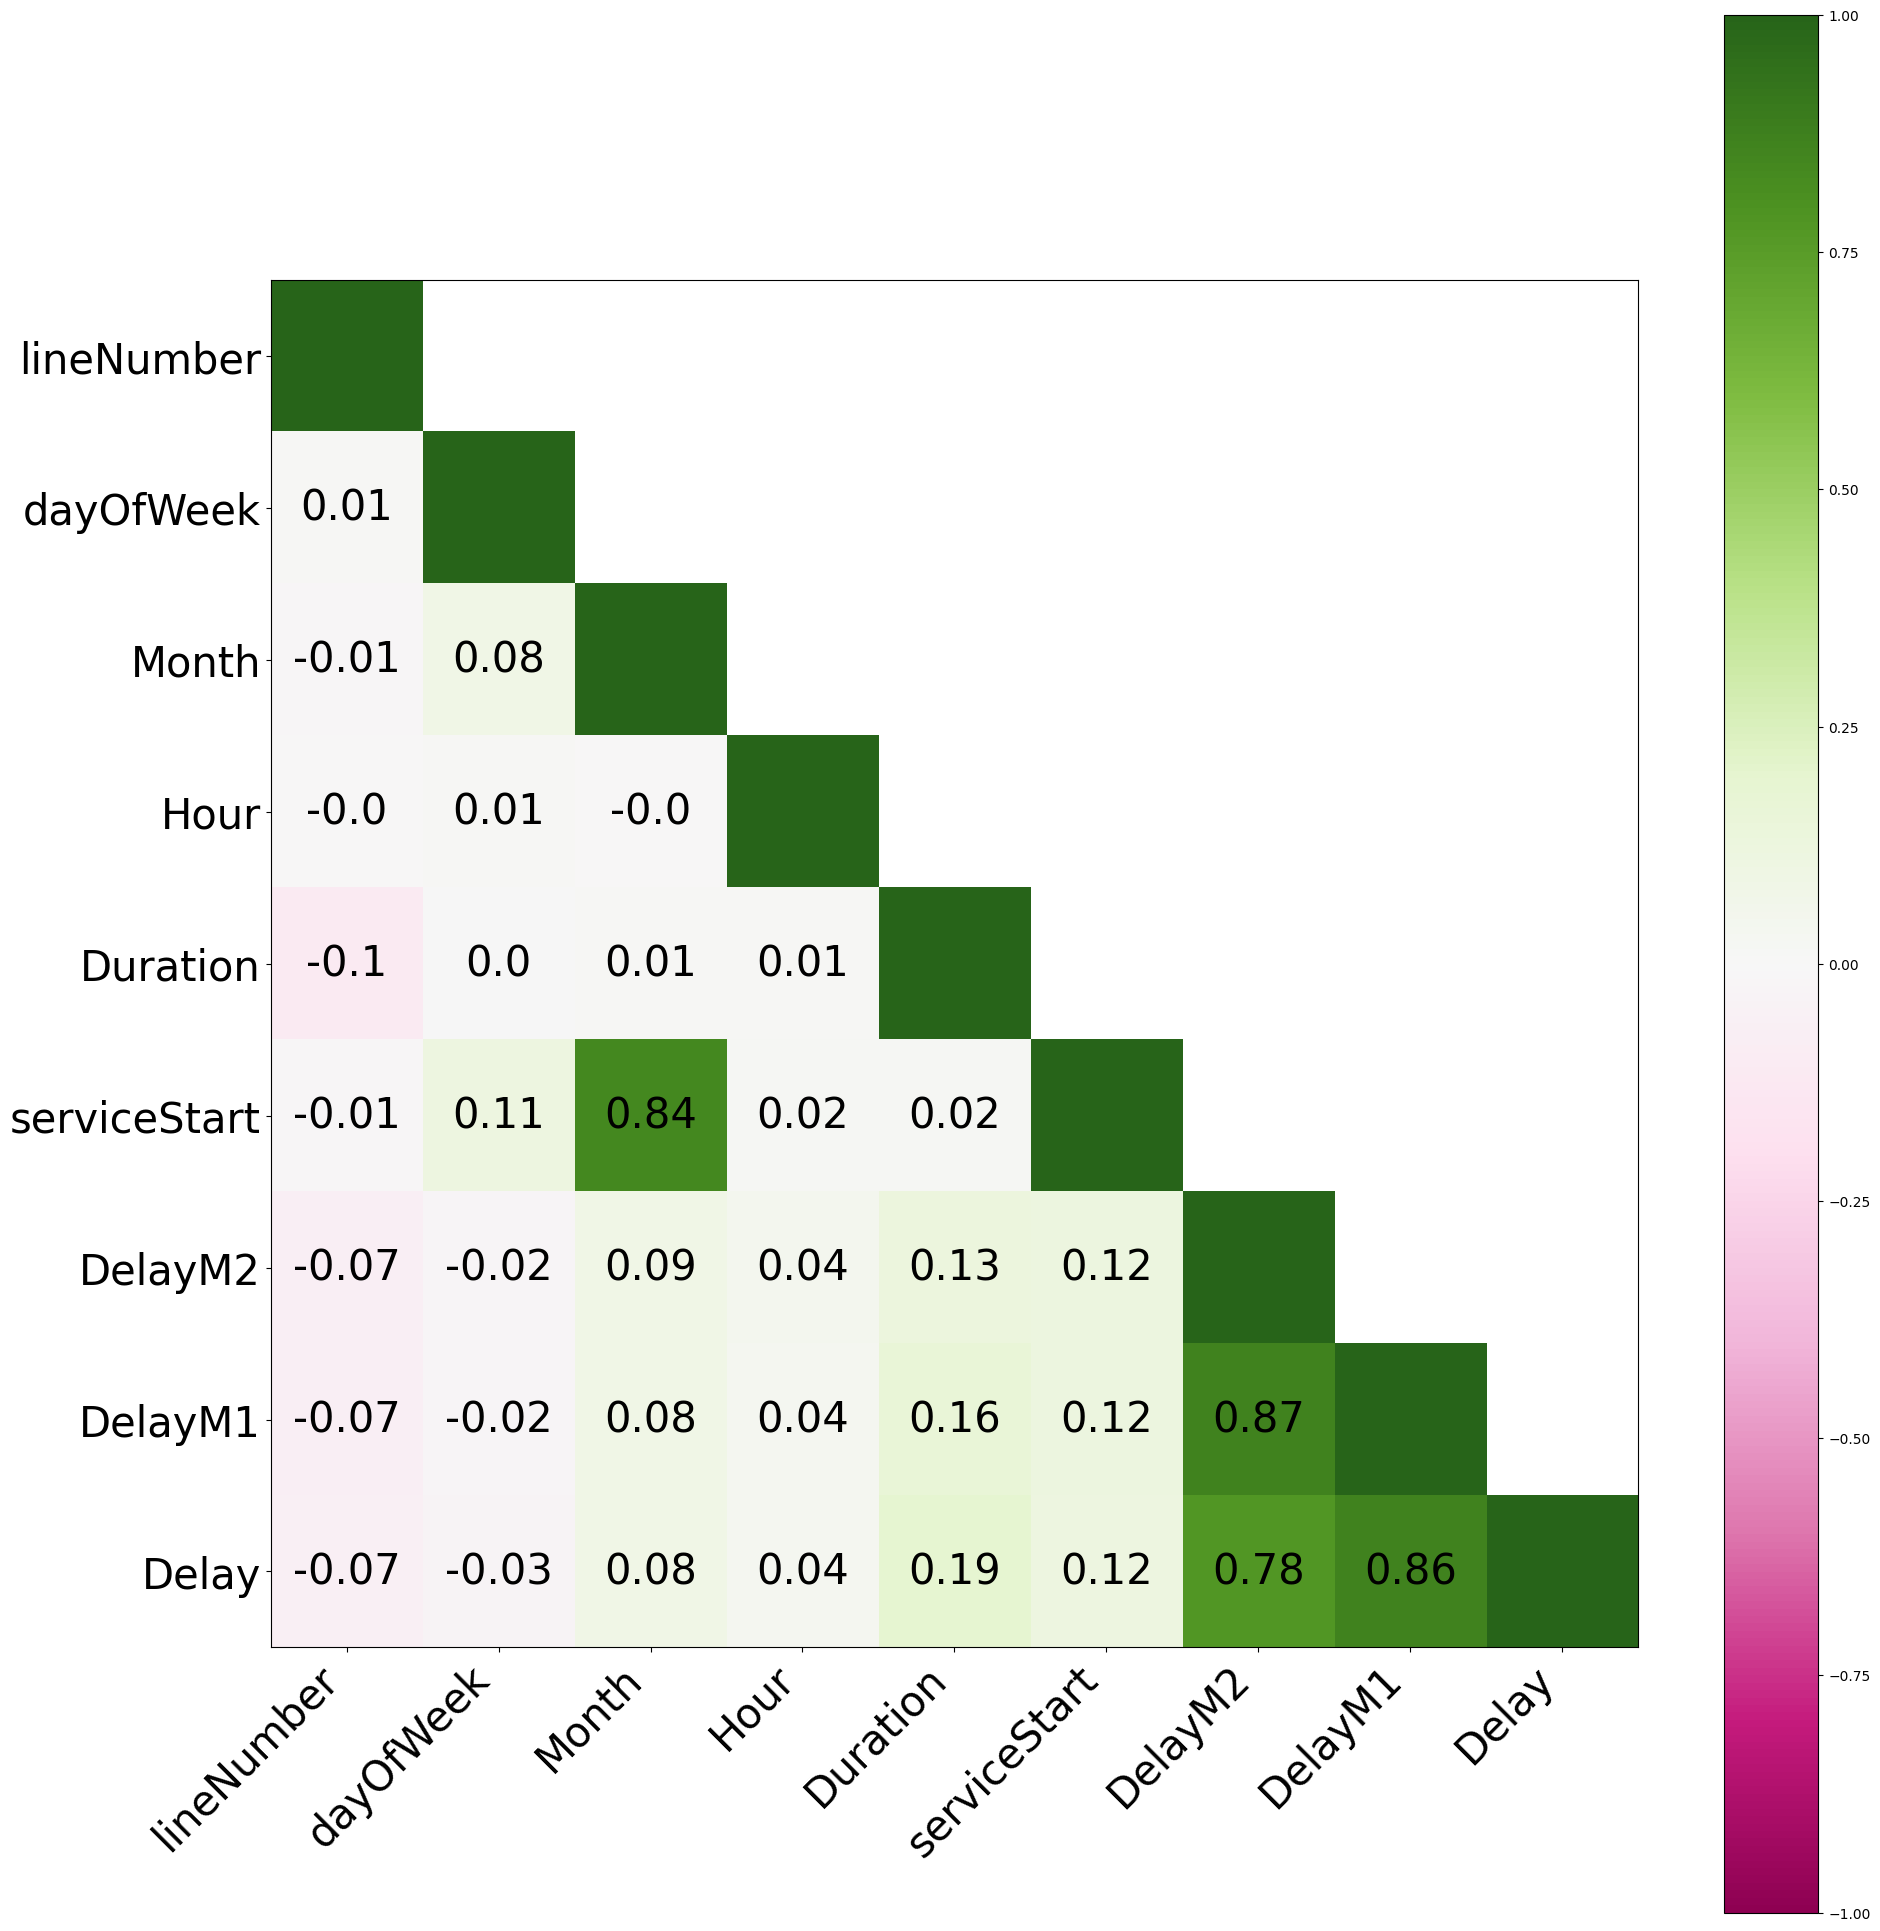

In [23]:
# Plot the correlation matrix

fontsize_corr = 30

# Define the size of plot with matplotlib.
plt.rcParams ['figure.figsize'] = [20, 20]

fig = plt.figure()

ax1 = fig.add_subplot(111)
# Some notes about add_subplot(pos)
#add_subplot(pos) is used: pos is a three digit integer, where the first digit is the number of rows,
#the second the number of columns, and the third the index of the subplot:
#i.e. fig.add_subplot(235) is the same as fig.add_subplot(2, 3, 5). 

cax1 = ax1.matshow(correlations_prefe_lt, vmin = -1, vmax = 1,  cmap=plt.get_cmap('PiYG'))
# Add a colorbar.
fig.colorbar(cax1)

# Set the x and y tick labels.
ticks = np.arange(0,len(names_fe_pre_en),1) # 0,1,...,6
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.set_xticklabels(names_fe_pre_en)
ax1.set_yticklabels(names_fe_pre_en)
ax1.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
# Set properties
plt.setp(ax1.get_xticklabels(), fontsize = fontsize_corr, rotation=45, horizontalalignment='right')
plt.setp(ax1.get_yticklabels(), fontsize = fontsize_corr)

# Display the correlation value in the matrix:
for k in range(len(names_fe_pre_en)):
    for j in range(k+1,len(names_fe_pre_en)):
        text = ax1.text(k, j, round(correlations_prefe_lt.iloc[j, k],2), \
                        ha="center", va="center", color="k", fontsize = fontsize_corr)

plt.tight_layout()

# Save the picture
filename = 'Correlations1x1_fe_pre'+ suffix_s_w
path = os.path.join(LustrePrefix,local_manipulation_plot_dir, filename)
plt.savefig(path)

## Only during the live course: You can stop here.

**EXERCISE 5 (cont.)**
* Complete all the blocks below with the missing argument for the **ticks** in the plot, so that the Notebook can run until the end.

# Correlation on 4 sets of columns
* Define 4 sets of feature columns to explore the correlation of data.

* Create 4 Pandas DataFrames as subsets of df_train_pd according to these columns.

In [24]:
# Feature columns:
# ori = original train schedule features
names_ori    = ['ZUGEREIGNIS_LINIE', 'SERVICE_ID', 'ZUGEREIGNIS_DS100', \
              'ZUGEREIGNIS_ZUGNUMMER','SERVICE_START_ZEIT', 'VERSPAETUNG']
names_ori_en = ['Line', 'serviceID', 'stationCode', \
              'trainNumber','serviceStart', 'Delay']

# fe = additional train schedule features (after data manipulation)
names_fe = ['WOCHENTAG_SOLL', 'MONAT',\
            'STUNDE_SOLL', 'MINUTE_SOLL', 'LAUFSZEIT', 'SERVICE_START_ZEIT', 'VERSPAETUNG']
names_fe_en = ['dayOfWeek', 'Month', \
               'Hour', 'Minute', 'Duration','serviceStart', 'Delay']

# fe_pre = includes train schedule features at the previous stations
names_fe_pre = ['MONAT', 'STUNDE_SOLL', 'MINUTE_SOLL', 'LAUFSZEIT', 'SERVICE_START_ZEIT',\
                'prev1_prev0_VERSPAETUNG', 'prev0_VERSPAETUNG', 'VERSPAETUNG']
names_fe_pre_en = ['Month', 'Hour', 'Minute', 'Duration', 'serviceStart',\
                   'delayM2', 'delayM1', 'Delay']

# fe_we = weather features
names_we = ['Mittelwerte_Temperatur', 'Mittelwerte_Rel_Feuchte', 'Mittel_WG','Max_WG', \
            'Summe_Niederschalg', 'Mittel_NO', 'Mittel_NO2', 'Mittel_O3', 'Mittel_PM10', \
            'VERSPAETUNG']
names_we_en = ['Temperature', 'Humidity', 'Wind','maxWind', \
               'Rain', 'NO', 'NO2', 'O3', 'PM10', \
               'delay']

# Technical issue:
# 4 subsets of df_train_pd are converted to Numpy arrays with np.float64 ...
np_train_ori = np.float64(df_train_pd[names_ori])
np_train_fe = np.float64(df_train_pd[names_fe])
np_train_prefe = np.float64(df_train_pd[names_fe_pre])
np_train_we = np.float64(df_train_pd[names_we])
# Additional comments:
# ((Three columns are float, and python skips them somehow by default.)) 
# ((All the other columns of the dataframe were in numpy-formats.))
# ((=> convert to have same data format))

# ... and converted back to Pandas DataFrames (in order to use .corr() )
df_train_ori_pd = pd.DataFrame(np_train_ori)
df_train_fe_pd = pd.DataFrame(np_train_fe)
df_train_prefe_pd = pd.DataFrame(np_train_prefe)
df_train_we_pd = pd.DataFrame(np_train_we)

In [25]:
# corr() computes pairwise the correlation of columns (with the Pearson Correlation Coefficient)
# and returns a correlation matrix:
correlations_ori      = df_train_ori_pd.corr()
correlations_ori_lt   = correlations_ori.where(np.tril(np.ones(correlations_ori.shape)).astype(bool))
correlations_fe       = df_train_fe_pd.corr()
correlations_fe_lt    = correlations_fe.where(np.tril(np.ones(correlations_fe.shape)).astype(bool))
correlations_we       = df_train_we_pd.corr()
correlations_we_lt    = correlations_we.where(np.tril(np.ones(correlations_we.shape)).astype(bool))
correlations_prefe    = df_train_prefe_pd.corr()
correlations_prefe_lt = correlations_prefe.where(np.tril(np.ones(correlations_prefe.shape)).astype(bool))

* **Plot** the **4 correlation matrices** in the same plot

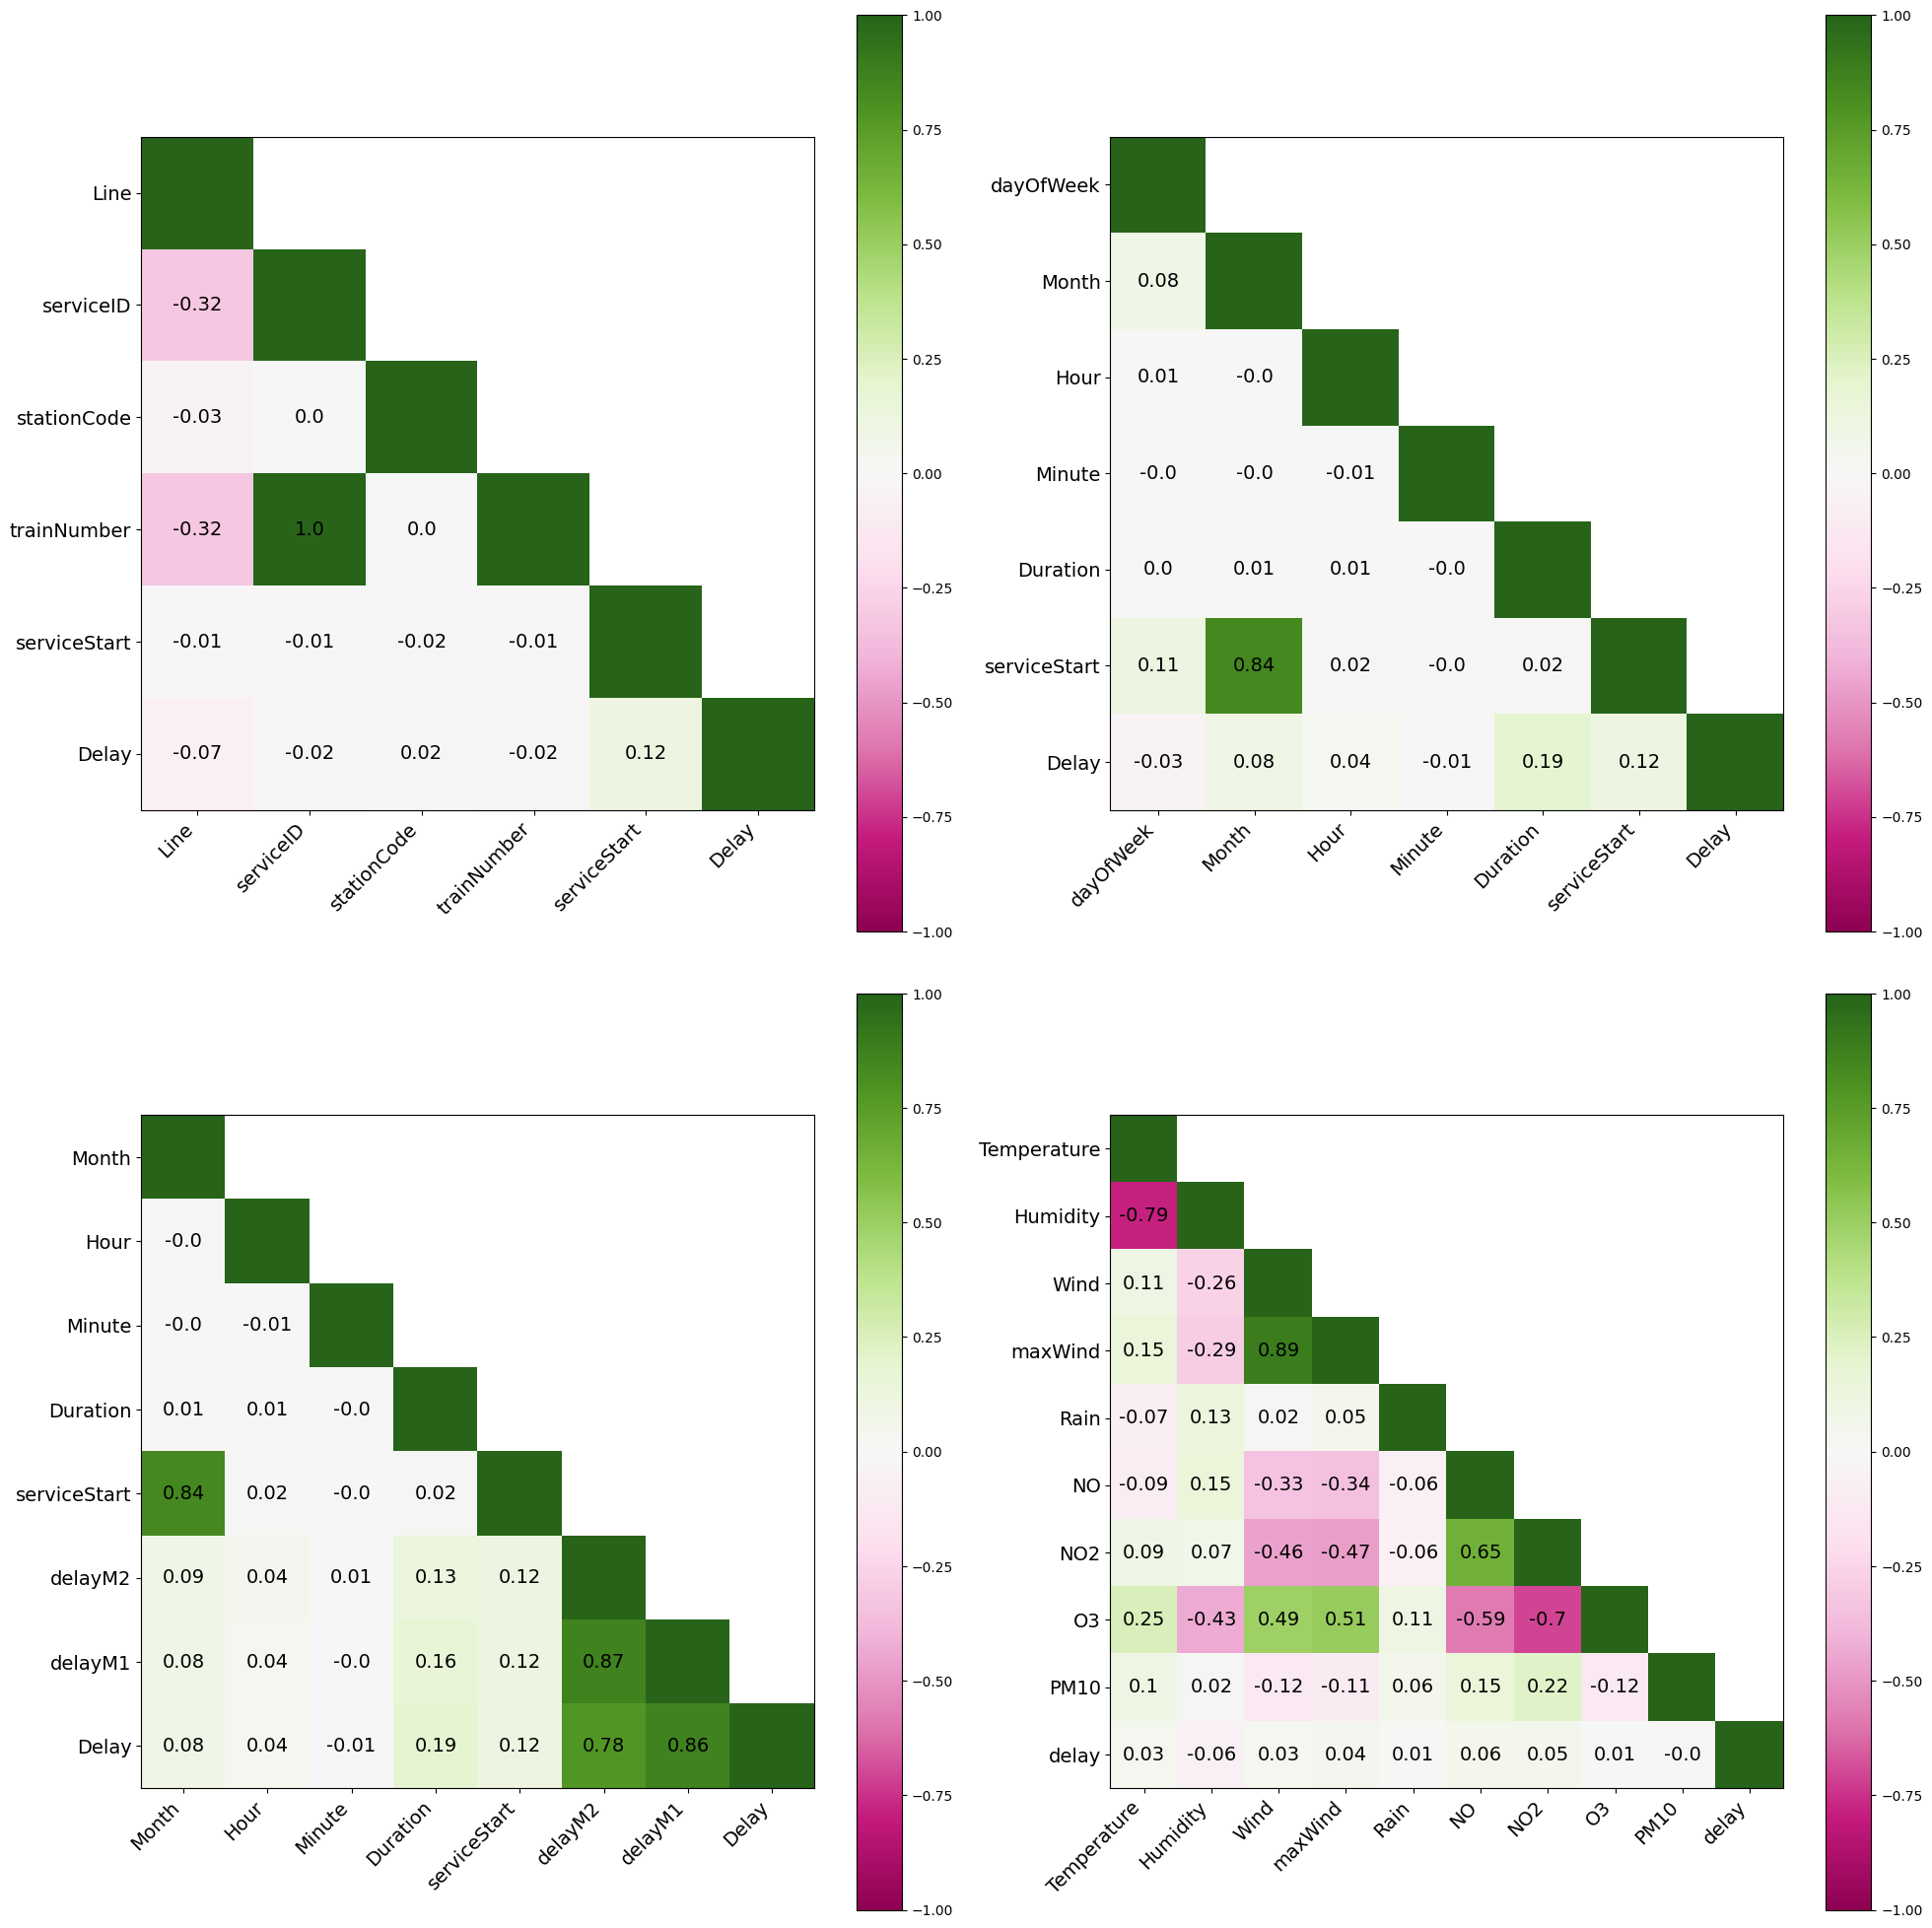

In [28]:
fontsize_corr = 14

#Define the size of plot with matplotlib:
plt.rcParams ['figure.figsize'] = [20, 20]

fig = plt.figure()

# 1st subplot: original train schedule features
ax1 = fig.add_subplot(221)
cax1 = ax1.matshow(correlations_ori_lt, vmin = -1, vmax = 1,  cmap=plt.get_cmap('PiYG'))
#Add a colorbar.
fig.colorbar(cax1)

#Set x and y tick labels.
ticks = np.arange(0,len(names_ori_en),1) #0,1,...,6
ax1.set_xticks(ticks)
ax1.set_yticks(ticks)
ax1.set_xticklabels(names_ori_en)
ax1.set_yticklabels(names_ori_en)
ax1.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
#Set properties
plt.setp(ax1.get_xticklabels(), fontsize = fontsize_corr, rotation=45, horizontalalignment='right')
plt.setp(ax1.get_yticklabels(), fontsize = fontsize_corr)

# Display the correlation value in the matrix:
for k in range(len(names_ori_en)):
    for j in range(k+1,len(names_ori_en)):
        text = ax1.text(k, j, round(correlations_ori_lt.iloc[j, k],2), \
                        ha="center", va="center", color="k", fontsize = fontsize_corr)

# The following 3 subplots are analogous.

# 2nd subplot: additional train schedule features (after data preparation)
ax2 = fig.add_subplot(222)
cax2 = ax2.matshow(correlations_fe_lt, vmin = -1, vmax = 1,  cmap=plt.get_cmap('PiYG'))
fig.colorbar(cax2)

ticks = np.arange(0,len(names_fe_en),1)
ax2.set_xticks(ticks)
ax2.set_yticks(ticks)
ax2.set_xticklabels(names_fe_en)
ax2.set_yticklabels(names_fe_en)
ax2.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
#Set properties
plt.setp(ax2.get_xticklabels(), fontsize = fontsize_corr, rotation=45, horizontalalignment='right')
plt.setp(ax2.get_yticklabels(), fontsize = fontsize_corr)
# Display the correlation value in the matrix:
for k in range(len(names_fe_en)):
    for j in range(k + 1, len(names_fe_en)):
        text = ax2.text(k, j, round(correlations_fe_lt.iloc[j, k], 2),
                        ha="center", va="center", color="k", fontsize=fontsize_corr)

# 3rd subplot: includes train schedule features at the previous stations 
ax3 = fig.add_subplot(223)
cax3 = ax3.matshow(correlations_prefe_lt, vmin = -1, vmax = 1,  cmap=plt.get_cmap('PiYG'))
fig.colorbar(cax3)

ticks = np.arange(0,len(names_fe_pre_en),1)
ax3.set_xticks(ticks)
ax3.set_yticks(ticks)
ax3.set_xticklabels(names_fe_pre_en)
ax3.set_yticklabels(names_fe_pre_en)
ax3.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
#Set properties
plt.setp(ax3.get_xticklabels(), fontsize = fontsize_corr, rotation=45, horizontalalignment='right')
plt.setp(ax3.get_yticklabels(), fontsize = fontsize_corr)

# Display the correlation value in the matrix:
for k in range(len(names_fe_pre_en)):
    for j in range(k + 1, len(names_fe_pre_en)):
        text = ax3.text(k, j, round(correlations_prefe_lt.iloc[j, k], 2),
                        ha="center", va="center", color="k", fontsize=fontsize_corr)

# 4th subplot: weather features
ax4 = fig.add_subplot(224)
cax4 = ax4.matshow(correlations_we_lt, vmin = -1, vmax = 1,  cmap=plt.get_cmap('PiYG'))
fig.colorbar(cax4)

ticks = np.arange(0,len(names_we_en),1)
ax4.set_xticks(ticks)
ax4.set_yticks(ticks)
ax4.set_xticklabels(names_we_en)
ax4.set_yticklabels(names_we_en)
ax4.tick_params(bottom=True, top=False, labelbottom=True, labeltop=False)
#Set properties
plt.setp(ax4.get_xticklabels(), fontsize = fontsize_corr, rotation=45, horizontalalignment='right')
plt.setp(ax4.get_yticklabels(), fontsize = fontsize_corr)

# Display the correlation value in the matrix:
for k in range(len(names_we_en)):
    for j in range(k + 1, len(names_we_en)):
        text = ax4.text(k, j, round(correlations_we_lt.iloc[j, k], 2),
                        ha="center", va="center", color="k", fontsize=fontsize_corr)

plt.tight_layout()

# Save the picture
filename = 'Correlations4'+suffix_s_w
path = os.path.join(LustrePrefix,local_manipulation_plot_dir, filename)
plt.savefig(path)